In [8]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.image import psnr, ssim

2026-02-27 16:49:23.012075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772210963.190415      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772210963.241793      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772210963.660679      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772210963.660721      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772210963.660724      55 computation_placer.cc:177] computation placer alr

In [38]:
import os
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.image import psnr, ssim
from tqdm import tqdm

# 🔥 FORCE FLOAT32 (VERY IMPORTANT)
tf.keras.mixed_precision.set_global_policy('float32')
# =========================================================
# CONFIG
# =========================================================
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25
DATA_DIR = "/kaggle/input/datasets/mubtasim180/bossbase-1-01-0-4-wow/BOSSBase 1.01 + 0.4 WOW/cover"

# =========================================================
# DATA SPLIT
# =========================================================
images = [os.path.join(DATA_DIR, img) for img in os.listdir(DATA_DIR) if img.endswith(".png")]
random.shuffle(images)

train_imgs, test_imgs = train_test_split(images, test_size=0.15, random_state=42)
train_imgs, val_imgs = train_test_split(train_imgs, test_size=0.176, random_state=42)

# =========================================================
# DATA GENERATOR
# =========================================================
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def data_generator(image_list):
    while True:
        random.shuffle(image_list)
        for i in range(0, len(image_list), BATCH_SIZE):
            batch = image_list[i:i+BATCH_SIZE]
            covers = [load_image(p) for p in batch]
            secrets = [load_image(p) for p in random.sample(image_list, len(batch))]
            yield tf.stack(covers), tf.stack(secrets)

train_gen = data_generator(train_imgs)

# =========================================================
# MODELS
# =========================================================
def build_secret_encoder():
    inp = layers.Input((256,256,3))
    x = layers.Conv2D(64,3,strides=2,padding='same',activation='relu')(inp)
    x = layers.Conv2D(128,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
    return Model(inp, x)

def build_encoder():
    cover_in = layers.Input((256,256,3))
    secret_latent = layers.Input((64,64,64))

    x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(secret_latent)
    x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

    cover_yuv = layers.Lambda(lambda x: tf.image.rgb_to_yuv(x))(cover_in)
    cover_y = layers.Lambda(lambda x: x[:,:,:,0:1])(cover_yuv)
    cover_uv = layers.Lambda(lambda x: x[:,:,:,1:3])(cover_yuv)

    combined = layers.Concatenate()([cover_uv, x])
    r = layers.Conv2D(64,3,padding='same',activation='relu')(combined)
    r = layers.Conv2D(2,3,padding='same',activation='tanh')(r)

    UV_SCALE = 0.05
    uv_stego = layers.Lambda(lambda inputs: inputs[0] + UV_SCALE * inputs[1])([cover_uv, r])

    stego_yuv = layers.Concatenate()([cover_y, uv_stego])
    stego_rgb = layers.Lambda(lambda x: tf.image.yuv_to_rgb(x))(stego_yuv)

    return Model([cover_in, secret_latent], stego_rgb)

def build_decoder():
    inp = layers.Input((256,256,3))

    x = layers.Conv2D(64,3,padding='same',activation='relu')(inp)
    x = layers.Conv2D(128,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2D(128,3,strides=2,padding='same',activation='relu')(x)

    latent = layers.Conv2D(64,3,padding='same',activation='relu')(x)

    s = layers.Conv2DTranspose(128,3,strides=2,padding='same',activation='relu')(latent)
    s = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(s)
    secret_rec = layers.Conv2D(3,3,padding='same',activation='sigmoid')(s)

    c = layers.Conv2DTranspose(128,3,strides=2,padding='same',activation='relu')(latent)
    c = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(c)
    cover_rec = layers.Conv2D(3,3,padding='same',activation='sigmoid')(c)

    return Model(inp, [secret_rec, cover_rec])

def build_discriminator():
    inp = layers.Input((256,256,3))
    x = layers.Conv2D(64,4,strides=2,padding='same',activation='relu')(inp)
    x = layers.Conv2D(128,4,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2D(256,4,strides=2,padding='same',activation='relu')(x)
    out = layers.Conv2D(1,4,padding='same',activation='sigmoid')(x)
    return Model(inp, out)

SE = build_secret_encoder()
E = build_encoder()
D = build_decoder()
C = build_discriminator()

opt_G = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
opt_D = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
bce = tf.keras.losses.BinaryCrossentropy()

# =========================================================
# TRAINING WITH PROGRESS BAR
# =========================================================
steps_per_epoch = len(train_imgs) // BATCH_SIZE

for epoch in range(EPOCHS):

    epoch_total = 0
    epoch_cover = 0
    epoch_secret = 0
    epoch_rev = 0
    epoch_psnr = 0
    epoch_d = 0

    progress_bar = tqdm(range(steps_per_epoch),
                        desc=f"Epoch {epoch+1}/{EPOCHS}",
                        leave=False)

    for step in progress_bar:

        covers, secrets = next(train_gen)

        # ---- Train D ----
        with tf.GradientTape() as tape_D:
            latent = SE(secrets)
            stego = E([covers, latent])
            real_out = C(covers)
            fake_out = C(stego)
            loss_D = bce(tf.ones_like(real_out), real_out) + \
                     bce(tf.zeros_like(fake_out), fake_out)

        grads_D = tape_D.gradient(loss_D, C.trainable_variables)
        opt_D.apply_gradients(zip(grads_D, C.trainable_variables))

        # ---- Train G ----
        with tf.GradientTape() as tape_G:
            latent = SE(secrets)
            stego = E([covers, latent])
            secret_rec, cover_rec = D(stego)
            fake_out = C(stego)

            loss_cover = tf.reduce_mean(tf.abs(covers - stego))
            loss_secret = tf.reduce_mean(tf.abs(secrets - secret_rec))
            loss_rev = tf.reduce_mean(tf.abs(covers - cover_rec))
            loss_adv = bce(tf.ones_like(fake_out), fake_out)
            loss_ssim = 1 - tf.reduce_mean(ssim(covers, stego, 1.0))

            total_loss = (
                1.0 * loss_cover +
                6.0 * loss_secret +
                3.0 * loss_rev +
                0.001 * loss_adv +
                0.5 * loss_ssim
            )

        vars_G = SE.trainable_variables + E.trainable_variables + D.trainable_variables
        grads_G = tape_G.gradient(total_loss, vars_G)
        opt_G.apply_gradients(zip(grads_G, vars_G))

        batch_psnr = tf.reduce_mean(psnr(covers, stego, 1.0))

        epoch_total += total_loss
        epoch_cover += loss_cover
        epoch_secret += loss_secret
        epoch_rev += loss_rev
        epoch_psnr += batch_psnr
        epoch_d += loss_D

        # ✅ Live metrics in progress bar
        progress_bar.set_postfix({
            "PSNR": f"{batch_psnr.numpy():.2f}",
            "G": f"{total_loss.numpy():.3f}",
            "D": f"{loss_D.numpy():.3f}"
        })

    # Average
    epoch_total /= steps_per_epoch
    epoch_cover /= steps_per_epoch
    epoch_secret /= steps_per_epoch
    epoch_rev /= steps_per_epoch
    epoch_psnr /= steps_per_epoch
    epoch_d /= steps_per_epoch

    # ✅ Horizontal Print
    print("=" * 130)
    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | "33
          f"PSNR: {epoch_psnr.numpy():.2f} dB | "
          f"Total: {epoch_total.numpy():.5f} | "
          f"Cover: {epoch_cover.numpy():.5f} | "
          f"Secret: {epoch_secret.numpy():.5f} | "
          f"Rev: {epoch_rev.numpy():.5f} | "
          f"D: {epoch_d.numpy():.5f}")
    print("=" * 130)

Epoch [001/25] | PSNR: 38.10 dB | Total: 0.75577 | Cover: 0.01596 | Secret: 0.08303 | Rev: 0.07282 | D: 0.79593


Epoch [002/25] | PSNR: 35.57 dB | Total: 0.43380 | Cover: 0.01451 | Secret: 0.04696 | Rev: 0.03861 | D: 0.65296


Epoch [003/25] | PSNR: 36.11 dB | Total: 0.39509 | Cover: 0.01352 | Secret: 0.04311 | Rev: 0.03364 | D: 0.50951


Epoch [004/25] | PSNR: 36.77 dB | Total: 0.37128 | Cover: 0.01248 | Secret: 0.04045 | Rev: 0.03110 | D: 0.43936


Epoch [005/25] | PSNR: 37.25 dB | Total: 0.35745 | Cover: 0.01173 | Secret: 0.03916 | Rev: 0.02901 | D: 0.46382


...

Epoch [021/25] | PSNR: 39.60 dB | Total: 0.23934 | Cover: 0.00697 | Secret: 0.02738 | Rev: 0.01601 | D: 0.44660


Epoch [022/25] | PSNR: 39.78 dB | Total: 0.23483 | Cover: 0.00670 | Secret: 0.02670 | Rev: 0.01557 | D: 0.39562


Epoch [023/25] | PSNR: 40.12 dB | Total: 0.23608 | Cover: 0.00634 | Secret: 0.02682 | Rev: 0.01525 | D: 0.37999


Epoch [024/25] | PSNR: 40.37 dB | Total: 0.23025 | Cover: 0.00609 | Secret: 0.02614 | Rev: 0.01510 | D: 0.36778


Epoch [025/25] | PSNR: 40.58 dB | Total: 0.23176 | Cover: 0.00593 | Secret: 0.02627 | Rev: 0.01479 | D: 0.32257


In [39]:
# =========================================================
# EVALUATION ON TEST SET
# =========================================================
print("\nRunning Evaluation on Test Set...\n")

def evaluate_model(image_list, num_samples=200):

    mse_cs = 0
    mse_cr = 0
    mse_sr = 0

    psnr_cs = 0
    psnr_cr = 0
    psnr_sr = 0

    ssim_cs = 0
    ssim_cr = 0
    ssim_sr = 0

    loss_cover_total = 0
    loss_secret_total = 0
    loss_rev_total = 0
    loss_adv_total = 0
    total_loss_total = 0

    count = 0

    for i in range(min(num_samples, len(image_list))):

        cover = load_image(image_list[i])
        secret = load_image(random.choice(image_list))

        cover = tf.expand_dims(cover, 0)
        secret = tf.expand_dims(secret, 0)

        latent = SE(secret, training=False)
        stego = E([cover, latent], training=False)
        secret_rec, cover_rec = D(stego, training=False)
        fake_out = C(stego, training=False)

        # ---- MSE ----
        mse_cs += tf.reduce_mean(tf.square(cover - stego))
        mse_cr += tf.reduce_mean(tf.square(cover - cover_rec))
        mse_sr += tf.reduce_mean(tf.square(secret - secret_rec))

        # ---- PSNR ----
        psnr_cs += tf.reduce_mean(psnr(cover, stego, 1.0))
        psnr_cr += tf.reduce_mean(psnr(cover, cover_rec, 1.0))
        psnr_sr += tf.reduce_mean(psnr(secret, secret_rec, 1.0))

        # ---- SSIM ----
        ssim_cs += tf.reduce_mean(ssim(cover, stego, 1.0))
        ssim_cr += tf.reduce_mean(ssim(cover, cover_rec, 1.0))
        ssim_sr += tf.reduce_mean(ssim(secret, secret_rec, 1.0))

        # ---- LOSSES ----
        loss_cover = tf.reduce_mean(tf.abs(cover - stego))
        loss_secret = tf.reduce_mean(tf.abs(secret - secret_rec))
        loss_rev = tf.reduce_mean(tf.abs(cover - cover_rec))
        loss_adv = bce(tf.ones_like(fake_out), fake_out)

        total_loss = (
            1.0 * loss_cover +
            6.0 * loss_secret +
            3.0 * loss_rev +
            0.001 * loss_adv +
            0.5 * (1 - tf.reduce_mean(ssim(cover, stego, 1.0)))
        )

        loss_cover_total += loss_cover
        loss_secret_total += loss_secret
        loss_rev_total += loss_rev
        loss_adv_total += loss_adv
        total_loss_total += total_loss

        count += 1

    # Average everything
    mse_cs /= count
    mse_cr /= count
    mse_sr /= count

    psnr_cs /= count
    psnr_cr /= count
    psnr_sr /= count

    ssim_cs /= count
    ssim_cr /= count
    ssim_sr /= count

    loss_cover_total /= count
    loss_secret_total /= count
    loss_rev_total /= count
    loss_adv_total /= count
    total_loss_total /= count

    # =========================================================
    # PRINT RESULTS CLEAN FORMAT
    # =========================================================
    print("\nMetric                               Value")
    print("----------------------------------------------------------")
    print(f"MSE (Cover→Stego)                {mse_cs.numpy():.6f}")
    print(f"MSE (Cover→Recovered)            {mse_cr.numpy():.6f}")
    print(f"MSE (Secret→Recovered Secret)    {mse_sr.numpy():.6f}")
    print(f"PSNR (Cover→Stego)               {psnr_cs.numpy():.6f}")
    print(f"PSNR (Cover→Recovered)           {psnr_cr.numpy():.6f}")
    print(f"PSNR (Secret→Recovered Secret)   {psnr_sr.numpy():.6f}")
    print(f"SSIM (Cover→Stego)               {ssim_cs.numpy():.6f}")
    print(f"SSIM (Cover→Recovered)           {ssim_cr.numpy():.6f}")
    print(f"SSIM (Secret→Recovered Secret)   {ssim_sr.numpy():.6f}")
    print(f"Loss_Cover                       {loss_cover_total.numpy():.6f}")
    print(f"Loss_Secret                      {loss_secret_total.numpy():.6f}")
    print(f"Loss_Reversibility               {loss_rev_total.numpy():.6f}")
    print(f"Loss_Adversarial                 {loss_adv_total.numpy():.6f}")
    print(f"Total_Loss                       {total_loss_total.numpy():.6f}")
    print("----------------------------------------------------------\n")

# Run evaluation
evaluate_model(test_imgs, num_samples=200)


Running Evaluation on Test Set...


Metric                               Value
----------------------------------------------------------
MSE (Cover→Stego)                0.000111
MSE (Cover→Recovered)            0.000703
MSE (Secret→Recovered Secret)    0.001438
PSNR (Cover→Stego)               40.508717
PSNR (Cover→Recovered)           33.100441
PSNR (Secret→Recovered Secret)   29.796991
SSIM (Cover→Stego)               0.987246
SSIM (Cover→Recovered)           0.939920
SSIM (Secret→Recovered Secret)   0.872206
Loss_Cover                       0.006011
Loss_Secret                      0.023827
Loss_Reversibility               0.016778
Loss_Adversarial                 18.757896
Total_Loss                       0.224442
----------------------------------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.033580426..0.89460534].


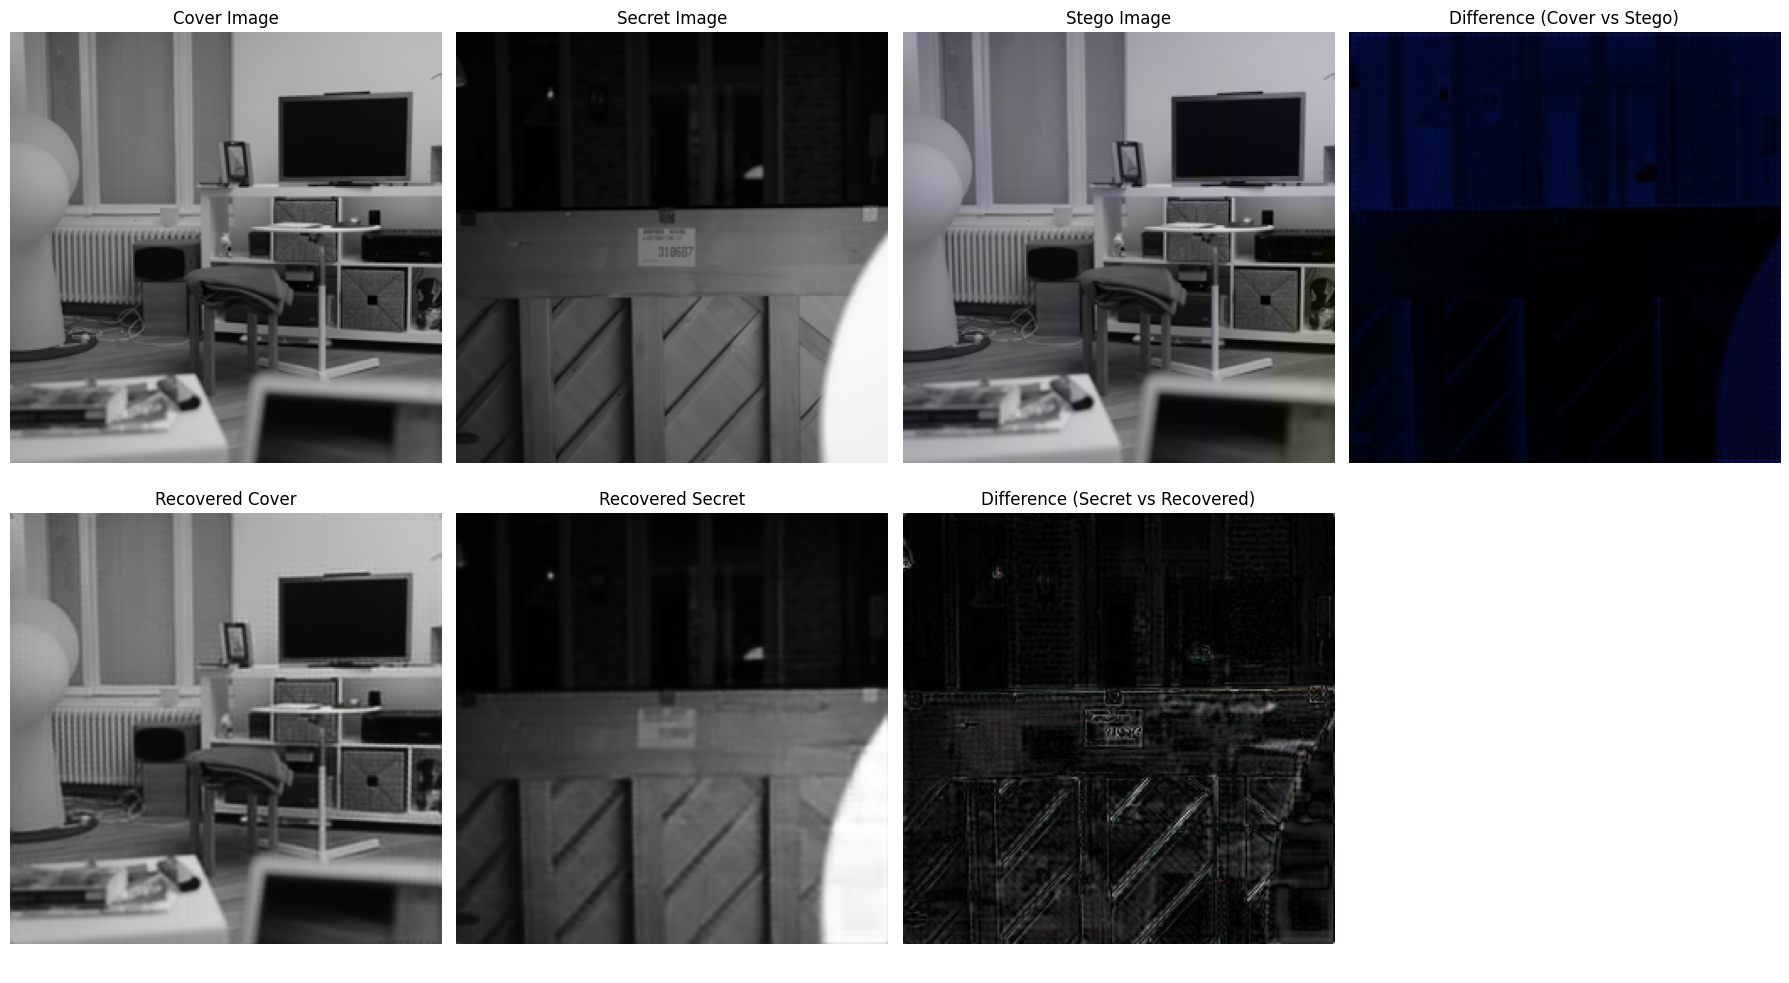

In [40]:
import matplotlib.pyplot as plt

# ==========================================
# TEST ON ONE SAMPLE
# ==========================================

def visualize_sample(image_list):

    # Pick random images
    cover_path = random.choice(image_list)
    secret_path = random.choice(image_list)

    cover = load_image(cover_path)
    secret = load_image(secret_path)

    cover_batch = tf.expand_dims(cover, 0)
    secret_batch = tf.expand_dims(secret, 0)

    # Forward pass
    latent = SE(secret_batch, training=False)
    stego = E([cover_batch, latent], training=False)
    secret_rec, cover_rec = D(stego, training=False)

    # Remove batch dimension
    stego = tf.squeeze(stego)
    secret_rec = tf.squeeze(secret_rec)
    cover_rec = tf.squeeze(cover_rec)

    # Difference maps
    diff_cover = tf.abs(cover - stego)
    diff_secret = tf.abs(secret - secret_rec)

    # ==========================================
    # PLOT
    # ==========================================
    fig, axs = plt.subplots(2, 4, figsize=(18, 10))

    axs[0,0].imshow(cover)
    axs[0,0].set_title("Cover Image")
    axs[0,0].axis("off")

    axs[0,1].imshow(secret)
    axs[0,1].set_title("Secret Image")
    axs[0,1].axis("off")

    axs[0,2].imshow(stego)
    axs[0,2].set_title("Stego Image")
    axs[0,2].axis("off")

    axs[0,3].imshow(diff_cover * 5)  # amplified for visibility
    axs[0,3].set_title("Difference (Cover vs Stego)")
    axs[0,3].axis("off")

    axs[1,0].imshow(cover_rec)
    axs[1,0].set_title("Recovered Cover")
    axs[1,0].axis("off")

    axs[1,1].imshow(secret_rec)
    axs[1,1].set_title("Recovered Secret")
    axs[1,1].axis("off")

    axs[1,2].imshow(diff_secret * 5)  # amplified
    axs[1,2].set_title("Difference (Secret vs Recovered)")
    axs[1,2].axis("off")

    axs[1,3].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization
visualize_sample(test_imgs)

In [41]:
# ==========================================
# SAVE MODELS
# ==========================================
import os

save_dir = "/kaggle/working/stego_models"
os.makedirs(save_dir, exist_ok=True)

SE.save(os.path.join(save_dir, "SecretEncoder.h5"))
E.save(os.path.join(save_dir, "Encoder.h5"))
D.save(os.path.join(save_dir, "Decoder.h5"))
C.save(os.path.join(save_dir, "Discriminator.h5"))

print("Models saved successfully!")

Models saved successfully!


In [43]:
# =========================================================
# FINAL PROFESSIONAL BACKUP SCRIPT (KERAS 3 SAFE)
# =========================================================

import os
import json
import shutil
import pandas as pd
from datetime import datetime

# =========================================================
# CREATE SAVE DIRECTORY
# =========================================================
save_dir = "/kaggle/working/Final_Stego_Backup"
os.makedirs(save_dir, exist_ok=True)

print("Saving everything to:", save_dir)

# =========================================================
# 1️⃣ SAVE FULL MODELS (.keras format - Recommended)
# =========================================================
SE.save(os.path.join(save_dir, "SecretEncoder.keras"))
E.save(os.path.join(save_dir, "Encoder.keras"))
D.save(os.path.join(save_dir, "Decoder.keras"))
C.save(os.path.join(save_dir, "Discriminator.keras"))

print("Full models saved in .keras format.")

# =========================================================
# 2️⃣ SAVE MODEL WEIGHTS (Correct Keras 3 Naming)
# =========================================================
SE.save_weights(os.path.join(save_dir, "SE.weights.h5"))
E.save_weights(os.path.join(save_dir, "E.weights.h5"))
D.save_weights(os.path.join(save_dir, "D.weights.h5"))
C.save_weights(os.path.join(save_dir, "C.weights.h5"))

print("Weights saved successfully.")

# =========================================================
# 3️⃣ SAVE HYPERPARAMETERS CONFIG
# =========================================================
config = {
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "Optimizer_G": "Adam",
    "Optimizer_D": "Adam",
    "Learning_Rate": 1e-4,
    "Beta_1": 0.5,
    "UV_SCALE": 0.05,
    "Loss_Weights": {
        "Cover": 1.0,
        "Secret": 6.0,
        "Reversibility": 3.0,
        "Adversarial": 0.001,
        "SSIM": 0.5
    },
    "Training_Date": str(datetime.now())
}

with open(os.path.join(save_dir, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Hyperparameter config saved.")

# =========================================================
# 4️⃣ SAVE TRAIN / TEST SPLIT
# =========================================================
split_data = {
    "train_images": train_imgs,
    "val_images": val_imgs,
    "test_images": test_imgs
}

with open(os.path.join(save_dir, "data_split.json"), "w") as f:
    json.dump(split_data, f, indent=4)

print("Dataset split saved.")

# =========================================================
# 5️⃣ SAVE FINAL EVALUATION METRICS
# (Make sure these variables exist from your evaluation step)
# =========================================================
try:
    final_metrics = {
        "MSE_Cover_Stego": float(mse_cs.numpy()),
        "MSE_Cover_Recovered": float(mse_cr.numpy()),
        "MSE_Secret_Recovered": float(mse_sr.numpy()),
        "PSNR_Cover_Stego": float(psnr_cs.numpy()),
        "PSNR_Cover_Recovered": float(psnr_cr.numpy()),
        "PSNR_Secret_Recovered": float(psnr_sr.numpy()),
        "SSIM_Cover_Stego": float(ssim_cs.numpy()),
        "SSIM_Cover_Recovered": float(ssim_cr.numpy()),
        "SSIM_Secret_Recovered": float(ssim_sr.numpy()),
        "Loss_Cover": float(loss_cover_total.numpy()),
        "Loss_Secret": float(loss_secret_total.numpy()),
        "Loss_Reversibility": float(loss_rev_total.numpy()),
        "Loss_Adversarial": float(loss_adv_total.numpy()),
        "Total_Loss": float(total_loss_total.numpy())
    }

    with open(os.path.join(save_dir, "final_metrics.json"), "w") as f:
        json.dump(final_metrics, f, indent=4)

    print("Final evaluation metrics saved.")

except:
    print("Evaluation variables not found — skipping metrics save.")

# =========================================================
# 6️⃣ OPTIONAL: SAVE TRAINING LOGS IF AVAILABLE
# =========================================================
try:
    training_log = pd.DataFrame({
        "Epoch": range(1, len(epoch_psnr_list) + 1),
        "PSNR": epoch_psnr_list,
        "Total_Loss": epoch_total_list,
        "Cover_Loss": epoch_cover_list,
        "Secret_Loss": epoch_secret_list,
        "Reversibility_Loss": epoch_rev_list,
        "D_Loss": epoch_d_list
    })

    training_log.to_csv(os.path.join(save_dir, "training_log.csv"), index=False)
    print("Training log saved.")

except:
    print("No epoch-wise logs found — skipping training log.")

# =========================================================
# 7️⃣ CREATE ZIP BACKUP
# =========================================================
zip_path = "/kaggle/working/Final_Stego_Backup.zip"
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', save_dir)

print("\nBackup ZIP created at:", zip_path)
print("ALL FILES SAVED SUCCESSFULLY ✅")

Saving everything to: /kaggle/working/Final_Stego_Backup
Full models saved in .keras format.
Weights saved successfully.
Hyperparameter config saved.
Dataset split saved.
Evaluation variables not found — skipping metrics save.
No epoch-wise logs found — skipping training log.

Backup ZIP created at: /kaggle/working/Final_Stego_Backup.zip
ALL FILES SAVED SUCCESSFULLY ✅
